# Simulation Evaluation
**Simulation Period:** 2016-05-17 → 2016-05-31 (14 days)

## Motivation

Using the `run_allocation_study` infrastructure, we ran the simulation under three different resource allocation methods (`SHORTEST_QUEUE`, `ADVANCED_LOCAL`, `ADVANCED_GLOBAL`), each with 5 replications. Since different allocation strategies are expected to yield different performance outcomes, we wanted to identify the best-performing individual run across all configurations and compare it against the real BPI 2017 event log.

## Evaluation Flow

| Step | Description |
|---|---|
| **1. Best Run Selection** | Score all 15 runs (3 configs × 5 replications) by a composite metric and pick the best |
| **2. Metric Analysis** | Compute and visualise all 4 metrics for the best run |
| **3. Comparison** | Compare best run against the real log |
| **4. Phase 4** | All configs (averaged over replications) vs real log for broader context |

## Metrics

| # | Metric | Definition | Direction |
|---|--------|------------|-----------| 
| 1 | **Average Cycle Time** | Mean wall-clock time per case |  lower is better |
| 2 | **Average Resource Occupation** | Mean fraction of shift time spent working |  higher is better |
| 3 | **(Weighted) Resource Fairness (MAD)** | Mean absolute deviation from average occupation |  lower is better |
| 4 | **Outcome Distribution Fidelity** | 1 − JSD between simulated and real outcome distributions | higher is better |

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

BASE = Path('..')
COLORS = {'advanced': "#DD528A"}

# Simulation period constants (14-day window)
SIM_START = datetime.date(2016, 5, 17)
SIM_END   = datetime.date(2016, 5, 31)
DAY_ZERO  = datetime.date(2016, 1, 1)   # DayId=0 anchor

# Only Workflow activities have explicit start/complete pairs
W_ACTIVITIES = [
    'W_Call after offers',
    'W_Call incomplete files',
    'W_Complete application',
    'W_Handle leads',
    'W_Validate application',
]

## Simulation Settings

| Component | Setting | File |
|---|---|---|
| **Decision Router** | `"advanced"` — C4.5 decision trees trained on real log | `decision_analysis/DPManager.py` |
| **Resource Allocator** | Per-config: shortest_queue / advanced_local / advanced_global | `resources/ResourceAllocator.py` |
| **Availability Schedule** | Shift-based, 140 resources | `availabilities_advanced.csv` |
| **Role Permissions** | Role-based activity gating | `role_permissions.csv` |
| **Processing Time Model** | QR model (`pt_use_qr=True`) | `Advanced_Model/proc_qr_bundle.joblib` |
| **Arrival Model** | `AdvancedSpawner` with NL holidays | `spawn_rates/` |
| **Simulation window** | 2016-05-17 09:15 → 2016-05-31 (14 days) | — |
| **Replications** | 5 per allocation config | — |

The routing strategy (Advanced Router) was selected based on the analysis in `simulation_evaluation/decision_evaluation/`.

## Simulation Production

Runs each allocation config (if CSVs don't exist yet) and saves results to `simulation_evaluation/resource_allocation/data/<config>/run_NN.csv`.  
**Skip this section** if CSVs are already present — the run loop checks before executing.

| Config | Method | delta | max_events | Rationale |
|---|---|---|---|---|
| `shortest_queue` | SHORTEST_QUEUE | — | 300k | Baseline, no RETRY |
| `advanced_local_d5` | ADVANCED_LOCAL | 5 | 600k | Existing working config |
| `advanced_global_d100` | ADVANCED_GLOBAL | 100 | 1M | High delta avoids RETRY cascade |

**Horizon:** 14 simulated calendar days (2016-05-17 → 2016-05-31), 5 replications per config.

In [168]:
SIM_DATA_ROOT = BASE / "simulation_evaluation" / "resource_allocation" / "data"

_CONFIG_DIRS = {
    "shortest_queue":       SIM_DATA_ROOT / "shortest_queue",
    "advanced_local_d5":    SIM_DATA_ROOT / "advanced_local_d5",
    "advanced_global_d100": SIM_DATA_ROOT / "advanced_global_d100",
}

def load_config_runs(config_dir):
    """Concatenate all run_NN.csv files for one config into a single DataFrame."""
    files = sorted(config_dir.glob("run_*.csv"))
    if not files:
        return pd.DataFrame()
    return pd.concat(
        [pd.read_csv(f, parse_dates=["time:timestamp"]) for f in files],
        ignore_index=True,
    )

config_logs = {name: load_config_runs(path) for name, path in _CONFIG_DIRS.items()}
for name, df in config_logs.items():
    print(f"  {name}: {len(df):,} rows, {df['case:concept:name'].nunique() if not df.empty else 0} cases")

  shortest_queue: 472,570 rows, 2020 cases
  advanced_local_d5: 84,531 rows, 720 cases
  advanced_global_d100: 357,792 rows, 1557 cases


In [169]:
# Resource schedules
avail_df = pd.read_csv(BASE / 'resources/availabilities/availabilities_advanced.csv')
avail_df['StartTime']   = pd.to_datetime(avail_df['StartTime'],   format='%H:%M:%S').dt.time
avail_df['EndTime']     = pd.to_datetime(avail_df['EndTime'],     format='%H:%M:%S').dt.time
avail_df['DurationMin'] = avail_df['DurationMin'].fillna(0).astype(int)

# Role assignments
roles_df   = pd.read_csv(BASE / 'resources/permissions/resource_roles.csv')
role_perms = pd.read_csv(BASE / 'resources/permissions/role_permissions.csv')

print(f"Resources in schedule : {avail_df['Resource'].nunique()}")
print(f"Config run dirs       : {list(_CONFIG_DIRS.keys())}")

Resources in schedule : 140
Config run dirs       : ['shortest_queue', 'advanced_local_d5', 'advanced_global_d100']


## Helper Functions

In [170]:
from scipy.spatial.distance import jensenshannon

# Metric helpers
def compute_cycle_times(df):
    """Return Series of per-case cycle time in hours."""
    ct = df.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
    return (ct['max'] - ct['min']).dt.total_seconds() / 3600


def compute_working_seconds(df):
    """
    Compute total working seconds per resource.
    Only W_* activities carry explicit start/complete pairs;
    Application (A_*) and Offer (O_*) events are instantaneous.
    """
    w = df[df['concept:name'].isin(W_ACTIVITIES)].copy()
    starts    = (w[w['lifecycle:transition'] == 'start']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'start_time'}))
    completes = (w[w['lifecycle:transition'] == 'complete']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'end_time'}))
    merged = pd.merge(starts, completes,
                      on=['case:concept:name', 'concept:name', 'org:resource'])
    merged['working_seconds'] = (
        (merged['end_time'] - merged['start_time'])
        .dt.total_seconds()
        .clip(lower=0)
    )
    return merged.groupby('org:resource')['working_seconds'].sum()


def compute_available_seconds(avail_df, start_date=SIM_START, end_date=SIM_END):
    """
    Compute total scheduled (available) seconds per resource
    across every day in [start_date, end_date], inclusive.
    DayId is defined as (date - 2016-01-01).days % 7
    """
    result = {}
    for resource, grp in avail_df.groupby('Resource'):
        total = 0.0
        day = start_date
        while day <= end_date:
            day_id = (day - DAY_ZERO).days % 7
            row = grp[grp['DayId'] == day_id]
            if not row.empty:
                r = row.iloc[0]
                shift_s = datetime.datetime.combine(day, r['StartTime'])
                shift_e = datetime.datetime.combine(day, r['EndTime'])
                secs = max(0.0, (shift_e - shift_s).total_seconds() - r['DurationMin'] * 60)
                total += secs
            day += datetime.timedelta(days=1)
        result[resource] = total
    return pd.Series(result, name='available_seconds')


def compute_occupation(working_s, available_s):
    """Return DataFrame with working, available, and occupation columns."""
    df = pd.DataFrame({'working_seconds': working_s,
                       'available_seconds': available_s})
    df['working_seconds'] = df['working_seconds'].fillna(0)
    df = df[df['available_seconds'] > 0].copy()
    df['occupation'] = (df['working_seconds'] / df['available_seconds']).clip(0, 1)
    return df


def fairness_metrics(occ_series, avail_seconds=None):
    """
    Returns:
      mean_occ   – mean occupation
      mad        – unweighted mean absolute deviation (lower -> fairer)
      wmad       – weighted MAD (weight = available_seconds fraction)
    """
    mean_occ = occ_series.mean()
    mad = (occ_series - mean_occ).abs().mean()
    if avail_seconds is not None:
        w = avail_seconds / avail_seconds.sum()
        wmad = (w * (occ_series - mean_occ).abs()).sum()
    else:
        wmad = np.nan
    return mean_occ, mad, wmad


# Outcome utility functions
OUTCOME_CATEGORIES = ['Cancelled', 'Pending', 'Refused', 'Complete', 'Accepted', 'Denied', 'Other']

_LAST_ACT_OUTCOME = {
    'A_Complete':  'Complete',
    'A_Accepted':  'Accepted',
    'O_Accepted':  'Accepted',
    'A_Denied':    'Denied',
    'O_Refused':   'Refused',
    'A_Cancelled': 'Cancelled',
    'O_Cancelled': 'Cancelled',
    'A_Pending':   'Pending',
}
TERMINAL_ACTS = set(_LAST_ACT_OUTCOME.keys())


def classify_outcomes(df, terminal_filter=True):
    last = (
        df.sort_values('time:timestamp')
          .groupby('case:concept:name')['concept:name']
          .last()
    )
    if terminal_filter:
        last = last[last.isin(TERMINAL_ACTS)]
    return last.map(lambda a: _LAST_ACT_OUTCOME.get(a, 'Other'))


def outcome_dist(series):
    counts = series.value_counts()
    total  = counts.sum()
    return {cat: counts.get(cat, 0) / total for cat in OUTCOME_CATEGORIES}


def jsd_outcomes(p, q):
    pv = np.array([p[k] for k in OUTCOME_CATEGORIES], dtype=float)
    qv = np.array([q[k] for k in OUTCOME_CATEGORIES], dtype=float)
    if pv.sum() > 0: pv /= pv.sum()
    if qv.sum() > 0: qv /= qv.sum()
    return float(jensenshannon(pv, qv))


# Scoring helper (used for best-run selection)
def _minmax(s, invert=False):
    lo, hi = s.min(), s.max()
    if hi == lo:
        return pd.Series(0.5, index=s.index)
    n = (s - lo) / (hi - lo)
    return 1 - n if invert else n

## Loading Real Log

In [171]:
import pm4py

# Load full real log.
# No period filtering for cycle time: filtering to cases completing within the
# simulation window retains only the fastest ~1 % of real cases (severe bias).
real_raw = pm4py.read_xes(str(BASE / 'data/BPI Challenge 2017.xes.gz'))
real_df  = pm4py.convert_to_dataframe(real_raw)
real_df['time:timestamp'] = pd.to_datetime(real_df['time:timestamp'], utc=True).dt.tz_localize(None)

real_log = real_df.copy()
real_ct  = compute_cycle_times(real_log)

n_real_cases = real_log['case:concept:name'].nunique()
print(f"Real log — {n_real_cases:,} cases, {len(real_log):,} events")
print(f"Avg CT real (full log): {real_ct.mean():.2f} h  ({real_ct.mean()/24:.1f} days)")


parsing log, completed traces :: 100%|██████████| 31509/31509 [00:46<00:00, 671.34it/s] 


Real log — 31,509 cases, 1,202,267 events
Avg CT real (full log): 525.59 h  (21.9 days)


In [172]:
REAL_COLOR = '#2ECC71'

# Complete-lifecycle events only (real log)
real_complete = (real_log[real_log['lifecycle:transition'].str.lower() == 'complete'].copy()
                 if 'lifecycle:transition' in real_log.columns else real_log.copy())

# Real log resource occupation (sim period only)
SIM_START_DT = pd.Timestamp('2016-05-17')
SIM_END_DT   = pd.Timestamp('2016-05-23')

real_w = real_df[
    real_df['concept:name'].isin(W_ACTIVITIES) &
    (real_df['time:timestamp'] >= SIM_START_DT) &
    (real_df['time:timestamp'] <  SIM_END_DT)
].copy()

r_starts    = (real_w[real_w['lifecycle:transition'].str.lower() == 'start']
               [['case:concept:name','concept:name','org:resource','time:timestamp']]
               .rename(columns={'time:timestamp':'start_time'}))
r_completes = (real_w[real_w['lifecycle:transition'].str.lower() == 'complete']
               [['case:concept:name','concept:name','org:resource','time:timestamp']]
               .rename(columns={'time:timestamp':'end_time'}))
real_pairs = pd.merge(r_starts, r_completes, on=['case:concept:name','concept:name','org:resource'])
real_pairs['working_seconds'] = (
    (real_pairs['end_time'] - real_pairs['start_time'])
    .dt.total_seconds().clip(lower=0)
)
real_work_period = real_pairs.groupby('org:resource')['working_seconds'].sum()

available = compute_available_seconds(avail_df)
real_occ_period = compute_occupation(real_work_period, available)
r_mean, r_mad, r_wmad = fairness_metrics(
    real_occ_period['occupation'], real_occ_period['available_seconds'])

print(f"Real log period W_ pairs: {len(real_pairs):,}  |  active resources: {len(real_work_period)}")
print(f"Real occupation: {r_mean*100:.2f}%   MAD: {r_mad:.4f}   wMAD: {r_wmad:.4f}")


Real log period W_ pairs: 236  |  active resources: 54
Real occupation: 2.25%   MAD: 0.0371   wMAD: 0.0399


## Best Run Selection

All configuration runs use the **Advanced Router** (C4.5 decision trees). We evaluate every individual run across all allocation configs, rank them by a composite score, and select the best-performing run as the simulation result.

**Composite score** — each metric is min-max normalised to [0, 1] (higher = better):

| Metric | Direction |
|--------|-----------|
| Avg Cycle Time | ↓ invert |
| Avg Resource Occupation | ↑ direct |
| Fairness MAD | ↓ invert |
| Outcome Fidelity (1−JSD) | ↑ direct |

`total_score = mean(score_ct, score_occ, score_fairness, score_fidelity)`

In [173]:
# Best Run Selection
# Real log outcome distribution used as fidelity reference
_ref_outcomes = classify_outcomes(real_complete, terminal_filter=True)
_ref_dist     = outcome_dist(_ref_outcomes)

_all_run_metrics = []
_run_dfs = {}

for cfg_name, cfg_dir in _CONFIG_DIRS.items():
    for f in sorted(cfg_dir.glob("run_*.csv")):
        key = f"{cfg_name}/{f.stem}"
        df  = pd.read_csv(f, parse_dates=["time:timestamp"])
        _run_dfs[key] = df

        ct   = compute_cycle_times(df)
        ct_f = ct[ct > 2]

        work  = compute_working_seconds(df)
        avail = compute_available_seconds(avail_df)
        occ   = compute_occupation(work, avail)
        _, mad, _ = fairness_metrics(occ["occupation"], occ["available_seconds"])

        outcomes = classify_outcomes(df, terminal_filter=True)
        fidelity = 1 - jsd_outcomes(_ref_dist, outcome_dist(outcomes))

        _all_run_metrics.append({
            "key":              key,
            "config":           cfg_name,
            "run":              f.stem,
            "CT Mean (h)":      ct_f.mean() if len(ct_f) > 0 else np.nan,
            "Occ Mean":         occ["occupation"].mean(),
            "Fairness MAD":     mad,
            "Outcome Fidelity": fidelity,
        })

_run_metrics_df = pd.DataFrame(_all_run_metrics)

# Composite scoring
_rm = _run_metrics_df.copy()
_rm["score_ct"]    = _minmax(_rm["CT Mean (h)"],      invert=True)
_rm["score_occ"]   = _minmax(_rm["Occ Mean"])
_rm["score_fair"]  = _minmax(_rm["Fairness MAD"],     invert=True)
_rm["score_fid"]   = _minmax(_rm["Outcome Fidelity"])
_rm["total_score"] = _rm[["score_ct", "score_occ", "score_fair", "score_fid"]].mean(axis=1)

_rm_sorted   = _rm.sort_values("total_score", ascending=False).reset_index(drop=True)
best_run_key = _rm_sorted.iloc[0]["key"]

# All downstream metric cells use `advanced_log`
advanced_log = _run_dfs[best_run_key]

print(f"Evaluated {len(_run_metrics_df)} runs across {len(_CONFIG_DIRS)} configs")
print(f"Best run : {best_run_key}  (total score: {_rm_sorted.iloc[0]['total_score']:.4f})\n")
print(_rm_sorted[["key", "CT Mean (h)", "Occ Mean", "Fairness MAD",
                   "Outcome Fidelity", "total_score"]].to_string(index=False))

Evaluated 15 runs across 3 configs
Best run : advanced_global_d100/run_03  (total score: 0.6663)

                        key  CT Mean (h)  Occ Mean  Fairness MAD  Outcome Fidelity  total_score
advanced_global_d100/run_03    14.208846  0.240538      0.242926          0.823732     0.666342
advanced_global_d100/run_00    16.137090  0.271664      0.271852          0.845265     0.656463
advanced_global_d100/run_01    14.771061  0.219314      0.235578          0.830473     0.648306
advanced_global_d100/run_02    16.010100  0.255123      0.270193          0.838853     0.631054
   advanced_local_d5/run_01    15.751962  0.122612      0.146806          0.839365     0.624967
      shortest_queue/run_02    16.074903  0.258030      0.285531          0.842242     0.623569
advanced_global_d100/run_04    15.064820  0.240814      0.263799          0.820804     0.613363
      shortest_queue/run_01    16.224090  0.267996      0.294231          0.833447     0.602482
      shortest_queue/run_00    16.5530

## Metric 1 – Average Cycle Time

**Definition:** The cycle time of a process instance is the elapsed wall-clock time from the moment the first event of that case is recorded until its last event.  
$$\overline{CT} = \frac{1}{|\mathcal{C}|} \sum_{c \in \mathcal{C}} (t^{\max}_c - t^{\min}_c)$$

A lower average cycle time means cases are completed faster -> a direct indicator of process efficiency.

In [174]:
# Filter to completed cases (> 2 events) before computing cycle time.
# Right-censored cases (spawned near end of simulation window) have only
# 2 events and a cycle time of ~0 h, pulling the median to 0 and distorting
# the mean. Completed cases give a meaningful cycle time distribution.
advanced_completed_ct = advanced_log[advanced_log['case:concept:name'].isin(
    advanced_log.groupby('case:concept:name').size()[lambda s: s > 2].index)]

advanced_ct = compute_cycle_times(advanced_completed_ct)
n_adv_comp  = len(advanced_ct)

print(f"Completed cases used for cycle time:")
print(f"  Advanced: {n_adv_comp} / {advanced_log['case:concept:name'].nunique()}"
      f" ({n_adv_comp/advanced_log['case:concept:name'].nunique()*100:.1f}%)")
print()

ct_summary = pd.DataFrame({
    'Mean (h)':    [advanced_ct.mean()],
    'Median (h)':  [advanced_ct.median()],
    'Std (h)':     [advanced_ct.std()],
    'Min (h)':     [advanced_ct.min()],
    'Max (h)':     [advanced_ct.max()],
    'Mean (days)': [advanced_ct.mean() / 24],
}, index=['Advanced Router'])

print('METRIC 1: AVERAGE CYCLE TIME (completed cases only)')
print(ct_summary.round(2).to_string())

Completed cases used for cycle time:
  Advanced: 1454 / 1454 (100.0%)

METRIC 1: AVERAGE CYCLE TIME (completed cases only)
                 Mean (h)  Median (h)  Std (h)  Min (h)  Max (h)  Mean (days)
Advanced Router      9.27        5.05     9.56     0.11    62.35         0.39


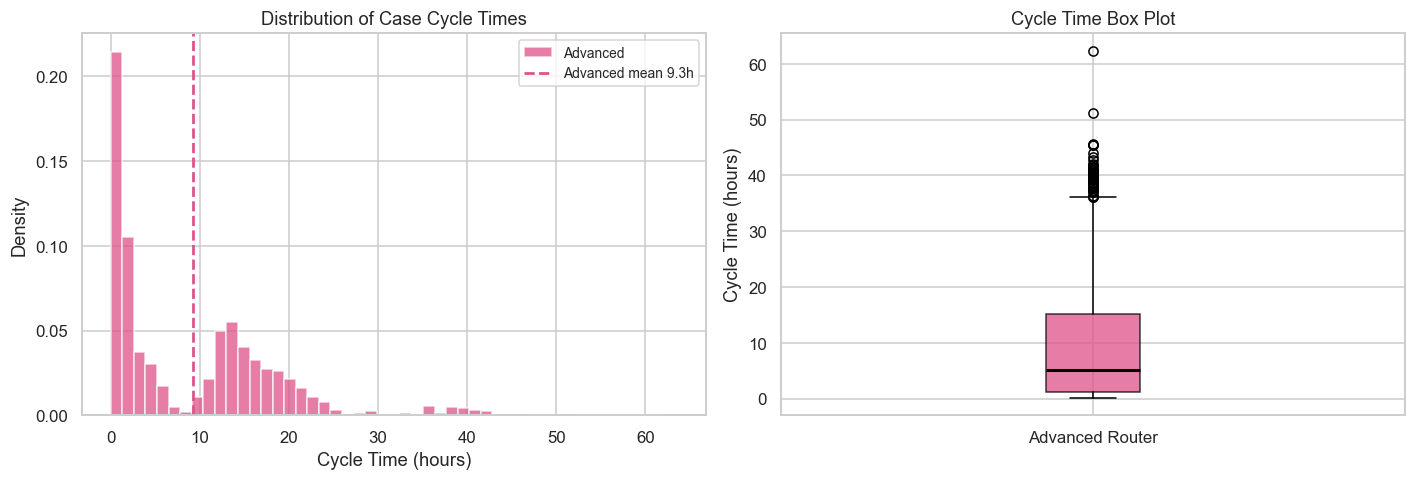

Saved -> results/metric1_cycle_time.png


In [175]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram
ax = axes[0]
bins = np.linspace(0, advanced_ct.max() * 1.02, 50)
ax.hist(advanced_ct, bins=bins, alpha=0.75, color=COLORS['advanced'], label='Advanced', density=True)
ax.axvline(advanced_ct.mean(), color=COLORS['advanced'], linestyle='--', lw=1.8,
           label=f'Advanced mean {advanced_ct.mean():.1f}h')
ax.set_xlabel('Cycle Time (hours)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Case Cycle Times')
ax.legend(fontsize=9)

# Right: boxplot
ax2 = axes[1]
bp = ax2.boxplot([advanced_ct.values], patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor(COLORS['advanced'])
bp['boxes'][0].set_alpha(0.75)
ax2.set_xticks([1])
ax2.set_xticklabels(['Advanced Router'])
ax2.set_ylabel('Cycle Time (hours)')
ax2.set_title('Cycle Time Box Plot')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric1_cycle_time.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric1_cycle_time.png')

## Metric 2 – Average Resource Occupation

**Definition:** For each resource $r$, occupation is the fraction of scheduled working time actually spent executing tasks:
$$\text{occ}(r) = \frac{\sum_{e\,:\,\text{resource}=r} (t^{\text{complete}}_e - t^{\text{start}}_e)}{\text{AvailableTime}(r)}$$

The **Average Resource Occupation** is the mean over all resources:  
$$\overline{\text{occ}} = \frac{1}{|\mathcal{R}|}\sum_{r \in \mathcal{R}} \text{occ}(r)$$

> **Note:** Only *Workflow* activities (`W_*`) have explicit `start` / `complete` event pairs in this simulator; Application (`A_*`) and Offer (`O_*`) events are instantaneous and do not contribute to working time.

In [176]:
print('Computing working time per resource...')
advanced_work = compute_working_seconds(advanced_log)

print('Computing available time per resource (iterating over schedule)...')
available = compute_available_seconds(avail_df)

advanced_occ = compute_occupation(advanced_work, available)

occ_summary = pd.DataFrame({
    'Mean Occupation':   [advanced_occ['occupation'].mean()],
    'Median Occupation': [advanced_occ['occupation'].median()],
    'Std':               [advanced_occ['occupation'].std()],
    'Max':               [advanced_occ['occupation'].max()],
    '# Resources':       [len(advanced_occ)],
}, index=['Advanced Router'])

print('\nMETRIC 2: AVERAGE RESOURCE OCCUPATION')
print((occ_summary * [100, 100, 100, 100, 1]).round(2).to_string())
print('(values in % except # Resources)')
print()
print(f"Advanced mean occupation: {advanced_occ['occupation'].mean()*100:.3f}%")

Computing working time per resource...
Computing available time per resource (iterating over schedule)...

METRIC 2: AVERAGE RESOURCE OCCUPATION
                 Mean Occupation  Median Occupation    Std    Max  # Resources
Advanced Router            24.05              10.83  32.14  100.0          140
(values in % except # Resources)

Advanced mean occupation: 24.054%


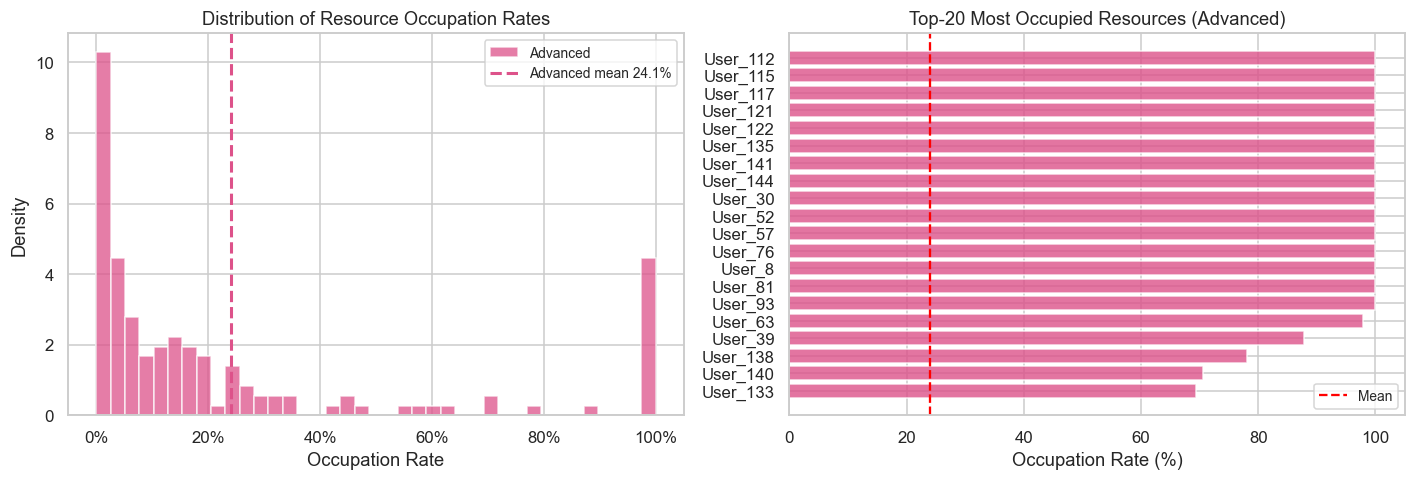

Saved -> results/metric2_resource_occupation.png


In [177]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: distribution of occupation rates
ax = axes[0]
bins = np.linspace(0, 1, 40)
ax.hist(advanced_occ['occupation'], bins=bins, alpha=0.75, color=COLORS['advanced'],
        label='Advanced', density=True)
ax.axvline(advanced_occ['occupation'].mean(), color=COLORS['advanced'], linestyle='--', lw=2,
           label=f"Advanced mean {advanced_occ['occupation'].mean()*100:.1f}%")
ax.set_xlabel('Occupation Rate')
ax.set_ylabel('Density')
ax.set_title('Distribution of Resource Occupation Rates')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=9)

# Right: top-20 most occupied resources (advanced)
ax2 = axes[1]
top20 = advanced_occ.nlargest(20, 'occupation')
ax2.barh(top20.index[::-1], top20['occupation'][::-1] * 100,
         color=COLORS['advanced'], alpha=0.8)
ax2.axvline(advanced_occ['occupation'].mean() * 100,
            color='red', linestyle='--', lw=1.5, label='Mean')
ax2.set_xlabel('Occupation Rate (%)')
ax2.set_title('Top-20 Most Occupied Resources (Advanced)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric2_resource_occupation.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric2_resource_occupation.png')

## Metric 3 – (Weighted) Resource Fairness

**Definition:** Fairness measures how evenly the workload is spread across resources. We use the **Mean Absolute Deviation (MAD)** from the average occupation:

$$\text{Fairness}_{\text{unweighted}} = \frac{1}{|\mathcal{R}|}\sum_{r}|\text{occ}(r) - \overline{\text{occ}}|$$

**Weighted variant** — resources with longer availability periods count more:

$$\text{Fairness}_{\text{weighted}} = \sum_{r} w_r \cdot |\text{occ}(r) - \overline{\text{occ}}|, \quad w_r = \frac{\text{AvailableTime}(r)}{\sum_{r'}\text{AvailableTime}(r')}$$

**Lower = fairer** (smaller deviation = more equal load distribution).

In [178]:
a_mean, a_mad, a_wmad = fairness_metrics(
    advanced_occ['occupation'], advanced_occ['available_seconds'])

def _active_occ(occ_frame, log):
    task_cnt = (
        log[log['lifecycle:transition'] == 'start']
        .groupby('org:resource').size()
    )
    return occ_frame[occ_frame.index.isin(task_cnt[task_cnt > 0].index)]

a_occ_active = _active_occ(advanced_occ, advanced_log)
_, a_mad_act, a_wmad_act = fairness_metrics(
    a_occ_active['occupation'], a_occ_active['available_seconds'])

fairness_summary = pd.DataFrame({
    'Mean Occupation':               [a_mean],
    'MAD (unweighted, all)':         [a_mad],
    'MAD (weighted, all)':           [a_wmad],
    'MAD (unweighted, active only)': [a_mad_act],
    'MAD (weighted, active only)':   [a_wmad_act],
    'Fairness Score (1-MAD, all)':   [1 - a_mad],
}, index=['Advanced Router'])

print('METRIC 3: RESOURCE FAIRNESS')
print(fairness_summary.round(5).to_string())
print()
print('Interpretation: Lower MAD = fairer workload distribution')
print(f"  Advanced – all: {a_mad:.5f} / {a_wmad:.5f}  |  active only: {a_mad_act:.5f} / {a_wmad_act:.5f}")
print(f"  (Active-only excludes {len(advanced_occ) - len(a_occ_active)} advanced resources with zero tasks)")

METRIC 3: RESOURCE FAIRNESS
                 Mean Occupation  MAD (unweighted, all)  MAD (weighted, all)  MAD (unweighted, active only)  MAD (weighted, active only)  Fairness Score (1-MAD, all)
Advanced Router          0.24054                0.24293              0.23244                         0.2517                      0.24092                      0.75707

Interpretation: Lower MAD = fairer workload distribution
  Advanced – all: 0.24293 / 0.23244  |  active only: 0.25170 / 0.24092
  (Active-only excludes 11 advanced resources with zero tasks)


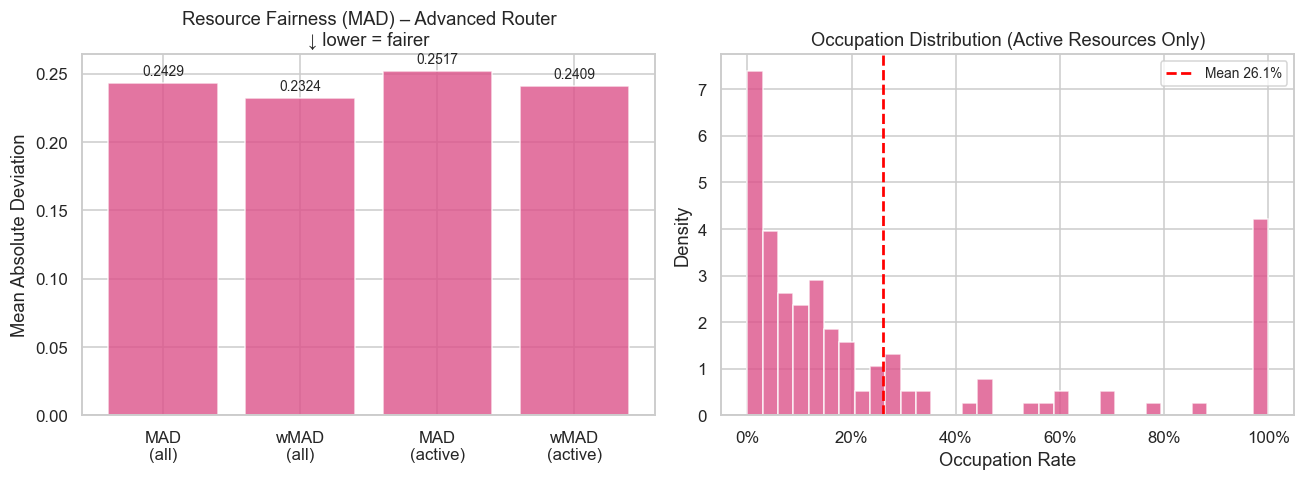

Saved -> results/metric3_resource_fairness.png


In [179]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: MAD comparison (all vs active-only, unweighted vs weighted)
ax = axes[0]
labels  = ['MAD\n(all)', 'wMAD\n(all)', 'MAD\n(active)', 'wMAD\n(active)']
values  = [a_mad, a_wmad, a_mad_act, a_wmad_act]
bars = ax.bar(labels, values, color=COLORS['advanced'], alpha=0.8, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.015,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Mean Absolute Deviation')
ax.set_title('Resource Fairness (MAD) – Advanced Router\n↓ lower = fairer')

# Right: occupation distribution of active resources only
ax2 = axes[1]
bins = np.linspace(0, 1, 35)
ax2.hist(a_occ_active['occupation'], bins=bins, color=COLORS['advanced'], alpha=0.8, density=True)
ax2.axvline(a_occ_active['occupation'].mean(), color='red', linestyle='--', lw=1.8,
            label=f"Mean {a_occ_active['occupation'].mean()*100:.1f}%")
ax2.set_xlabel('Occupation Rate')
ax2.set_ylabel('Density')
ax2.set_title('Occupation Distribution (Active Resources Only)')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric3_resource_fairness.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric3_resource_fairness.png')

## Metric 4 – Outcome Distribution Fidelity

**Definition:** Each case is classified into one of six outcome categories based on which terminal activities appear in its trace. Priority order reflects the three process paths in BPI 2017:

| Process Path | Terminal activity | Outcome label |
|---|---|---|
| Initiating Process | `A_Complete` | **Complete** |
| Initiating Process (partial) | `A_Accepted` or `O_Accepted` | **Accepted** |
| Pending Process | `A_Denied` | **Denied** |
| Pending Process | `O_Refused` | **Refused** |
| Not Pending / Pending | `A_Cancelled` or `O_Cancelled` | **Cancelled** |
| Pending Process | `A_Pending` | **Pending** |
| — | none of the above | **Other** |

The fidelity score is defined as:
$$\text{Fidelity} = 1 - \text{JSD}(P_{\text{sim}} \,\|\, P_{\text{real}})$$

where $\text{JSD}$ is the Jensen–Shannon Distance between the simulated and real outcome distributions. A fidelity of **1.0** means perfect agreement; **0.0** means maximum divergence.

In [180]:
OUTCOME_COLORS = {
    'Cancelled': '#E74C3C',
    'Pending':   "#ED9D1D",
    'Refused':   "#8B32B1",
    'Complete':  "#37F285",
    'Accepted':  "#09A048",
    'Denied':    "#901508",
    'Other':     "#B5B8BA",
}

In [181]:
# Metric 4: Outcome Distribution Fidelity
real_outcomes = classify_outcomes(real_complete, terminal_filter=True)
adv_outcomes  = classify_outcomes(advanced_log,  terminal_filter=True)

real_dist_out = outcome_dist(real_outcomes)
adv_dist_out  = outcome_dist(adv_outcomes)

n_real_total    = real_log['case:concept:name'].nunique()
n_real_terminal = len(real_outcomes)
n_adv_terminal  = len(adv_outcomes)

jsd_a      = jsd_outcomes(real_dist_out, adv_dist_out)
fidelity_a = 1 - jsd_a

comp_df = pd.DataFrame({
    'Outcome':       OUTCOME_CATEGORIES,
    'Real (%)':      [real_dist_out[o] * 100 for o in OUTCOME_CATEGORIES],
    'Best Run (%)':  [adv_dist_out[o]  * 100 for o in OUTCOME_CATEGORIES],
})

print(f"METRIC 4: OUTCOME DISTRIBUTION FIDELITY  [{best_run_key}]")
print(f"  Real reference  : {n_real_terminal:,} terminal / {n_real_total:,} total ({n_real_terminal/n_real_total*100:.1f}%)")
print(f"  Best run        : {n_adv_terminal:,} terminal / {advanced_log['case:concept:name'].nunique():,} cases\n")
print(comp_df.round(1).to_string(index=False))
print(f"\n  JSD      : {jsd_a:.4f}")
print(f"  Fidelity : {fidelity_a:.4f}")

real_ct = compute_cycle_times(real_log)
print(f"\nAvg CT real (full log) : {real_ct.mean():.2f} h  ({real_ct.mean()/24:.1f} days)")
print(f"Avg CT best run sim    : {advanced_ct.mean():.2f} h  ({advanced_ct.mean()/24:.2f} days)")
print(f"Compression ratio      : {real_ct.mean()/advanced_ct.mean():.0f}×")

METRIC 4: OUTCOME DISTRIBUTION FIDELITY  [advanced_global_d100/run_03]
  Real reference  : 26,485 terminal / 31,509 total (84.1%)
  Best run        : 1,434 terminal / 1,454 cases

  Outcome  Real (%)  Best Run (%)
Cancelled      53.5          73.4
  Pending      38.8          16.9
  Refused       7.5           9.7
 Complete       0.1           0.1
 Accepted       0.0           0.0
   Denied       0.1           0.0
    Other       0.0           0.0

  JSD      : 0.1763
  Fidelity : 0.8237

Avg CT real (full log) : 525.59 h  (21.9 days)
Avg CT best run sim    : 9.27 h  (0.39 days)
Compression ratio      : 57×


## Summary Dashboard – Advanced Router

**Higher fidelity (lower JSD)** → routing decisions lead to realistic process outcomes. Reference is the real log **filtered to terminal cases only** (cases whose last activity is a known outcome activity), excluding right-censored cases still in-flight at observation cutoff.

In [182]:
summary = pd.DataFrame({
    'Metric': [
        'Avg Cycle Time (h)',
        'Avg Cycle Time (days)',
        'Avg Resource Occupation (%)',
        'Fairness – MAD (unweighted)',
        'Fairness – MAD (weighted)',
        'Outcome Fidelity (1 − JSD)',
    ],
    'Advanced Router': [
        round(advanced_ct.mean(), 2),
        round(advanced_ct.mean() / 24, 3),
        round(advanced_occ['occupation'].mean() * 100, 3),
        round(a_mad, 5),
        round(a_wmad, 5),
        round(fidelity_a, 4),
    ],
})

print('         EVALUATION SUMMARY – ADVANCED ROUTER')
print(summary.to_string(index=False))
print()
print('Note: Cycle Time and Fairness MAD  → lower is better.')
print('      Resource Occupation          → higher is better.')
print('      Outcome Fidelity (1 − JSD)   → higher is better.')

         EVALUATION SUMMARY – ADVANCED ROUTER
                     Metric  Advanced Router
         Avg Cycle Time (h)          9.27000
      Avg Cycle Time (days)          0.38600
Avg Resource Occupation (%)         24.05400
Fairness – MAD (unweighted)          0.24293
  Fairness – MAD (weighted)          0.23244
 Outcome Fidelity (1 − JSD)          0.82370

Note: Cycle Time and Fairness MAD  → lower is better.
      Resource Occupation          → higher is better.
      Outcome Fidelity (1 − JSD)   → higher is better.


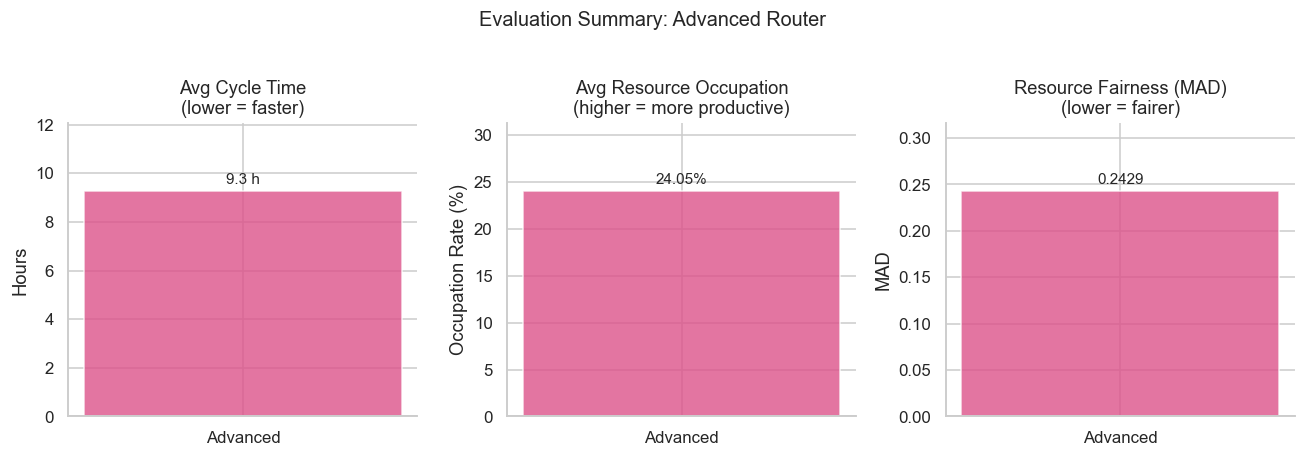

Saved -> results/summary_dashboard.png


In [183]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Cycle Time
ax = axes[0]
vals = [advanced_ct.mean()]
bars = ax.bar(['Advanced'], vals, color=[COLORS['advanced']], alpha=0.8, width=0.4)
ax.bar_label(bars, fmt='%.1f h', padding=3, fontsize=10)
ax.set_ylabel('Hours')
ax.set_title('Avg Cycle Time\n(lower = faster)')
ax.set_ylim(0, max(vals) * 1.3)

# Resource Occupation
ax2 = axes[1]
vals2 = [advanced_occ['occupation'].mean() * 100]
bars2 = ax2.bar(['Advanced'], vals2, color=[COLORS['advanced']], alpha=0.8, width=0.4)
ax2.bar_label(bars2, fmt='%.2f%%', padding=3, fontsize=10)
ax2.set_ylabel('Occupation Rate (%)')
ax2.set_title('Avg Resource Occupation\n(higher = more productive)')
ax2.set_ylim(0, max(vals2) * 1.3)

# Fairness (unweighted MAD)
ax3 = axes[2]
vals3 = [a_mad]
bars3 = ax3.bar(['Advanced'], vals3, color=[COLORS['advanced']], alpha=0.8, width=0.4)
ax3.bar_label(bars3, fmt='%.4f', padding=3, fontsize=10)
ax3.set_ylabel('MAD')
ax3.set_title('Resource Fairness (MAD)\n(lower = fairer)')
ax3.set_ylim(0, max(vals3) * 1.3)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Evaluation Summary: Advanced Router', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'summary_dashboard.png', bbox_inches='tight')
plt.show()
print('Saved -> results/summary_dashboard.png')

## Simulation Validation – Best Run vs Real Log

> **Scope note:** The full real log is used without period filtering. Filtering to cases that start and complete within the simulation window would retain only the fastest ~1% of real cases, introducing severe selection bias. Absolute cycle time values are not expected to match due to simulation time compression; distribution shape and compression ratio are the meaningful comparison points.

### Validation – Metric 1: Cycle Time vs Real Log

> **Methodological note:** The simulation compresses external waiting times (inter-arrival queuing, manual review delays, overnight gaps) that are present in the real process but not modelled. This means cycle times will never match numerically — the gap is structural, not a simulation error.  
> The **full real log** (31,509 cases) is used to avoid selection bias: filtering to only cases that complete within the 18-day sim window would retain only the fastest ~1% of real cases, making the comparison misleading. Distribution shape and compression ratio are the meaningful indicators here.

### Metric 1 – Cycle Time: Best Run vs Real Log

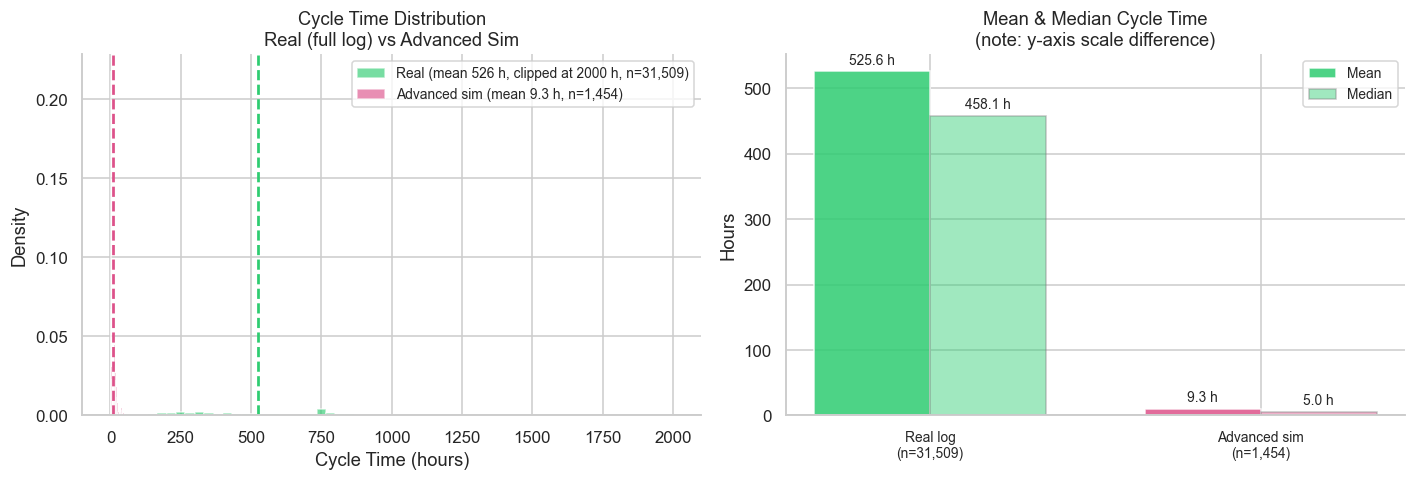

Real log mean CT  : 525.59 h  (21.9 days)
Advanced sim mean : 9.27 h  (0.39 days)
Compression ratio : 57×
Saved -> results/validation_cycle_time.png


In [184]:
n_real_ct = len(real_ct)
n_adv_ct  = len(advanced_ct)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: overlapping histograms (clip real log for readability)
ax = axes[0]
clip_h = 2000
ax.hist(real_ct.clip(upper=clip_h), bins=60, alpha=0.65, color=REAL_COLOR,
        density=True, label=f'Real (mean {real_ct.mean():.0f} h, clipped at {clip_h} h, n={n_real_ct:,})')
ax.hist(advanced_ct, bins=40, alpha=0.65, color=COLORS['advanced'],
        density=True, label=f'Advanced sim (mean {advanced_ct.mean():.1f} h, n={n_adv_ct:,})')
ax.axvline(min(real_ct.mean(), clip_h), color=REAL_COLOR,         linestyle='--', lw=1.8)
ax.axvline(advanced_ct.mean(),          color=COLORS['advanced'], linestyle='--', lw=1.8)
ax.set_xlabel('Cycle Time (hours)')
ax.set_ylabel('Density')
ax.set_title('Cycle Time Distribution\nReal (full log) vs Advanced Sim')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: mean / median bar comparison
ax2 = axes[1]
labels_ct = [f'Real log\n(n={n_real_ct:,})', f'Advanced sim\n(n={n_adv_ct:,})']
means   = [real_ct.mean(),   advanced_ct.mean()]
medians = [real_ct.median(), advanced_ct.median()]
x = np.arange(2)
w = 0.35
bars_m  = ax2.bar(x - w/2, means,   w, color=[REAL_COLOR, COLORS['advanced']], alpha=0.85, label='Mean')
bars_md = ax2.bar(x + w/2, medians, w, color=[REAL_COLOR, COLORS['advanced']], alpha=0.45, label='Median', edgecolor='grey')
ax2.bar_label(bars_m,  fmt='%.1f h', padding=3, fontsize=9)
ax2.bar_label(bars_md, fmt='%.1f h', padding=3, fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(labels_ct, fontsize=9)
ax2.set_ylabel('Hours')
ax2.set_title('Mean & Median Cycle Time\n(note: y-axis scale difference)')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validation_cycle_time.png', bbox_inches='tight')
plt.show()
print(f"Real log mean CT  : {real_ct.mean():.2f} h  ({real_ct.mean()/24:.1f} days)")
print(f"Advanced sim mean : {advanced_ct.mean():.2f} h  ({advanced_ct.mean()/24:.2f} days)")
print(f"Compression ratio : {real_ct.mean()/advanced_ct.mean():.0f}×")
print('Saved -> results/validation_cycle_time.png')

### Validation – Metrics 2 & 3: Resource Occupation & Fairness vs Real Log

> **Methodological note:** For resource metrics, filtering by case completion would bias toward fast cases. Instead we use **all W_ `start`/`complete` event pairs whose timestamps fall within the simulation period** (2016-05-17 → 2016-06-04), regardless of whether the case started or finished in the window. This gives an unbiased picture of what resources were actually doing during the same 18 days.
>
> The same resource availability schedule is used for both real log and simulation.

In [185]:
SIM_START_DT = pd.Timestamp('2016-05-17')
SIM_END_DT   = pd.Timestamp('2016-06-05')  # exclusive upper bound

# Filter real_df to W_ activities within the sim period
real_w = real_df[
    real_df['concept:name'].isin(W_ACTIVITIES) &
    (real_df['time:timestamp'] >= SIM_START_DT) &
    (real_df['time:timestamp'] <  SIM_END_DT)
].copy()

# Determine lifecycle column (the real log uses 'lifecycle:transition')
lc_col = 'lifecycle:transition'
if lc_col not in real_w.columns:
    lc_col = None

if lc_col:
    real_w_starts    = real_w[real_w[lc_col].str.lower() == 'start']
    real_w_completes = real_w[real_w[lc_col].str.lower() == 'complete']
else:
    # Fallback: first and last event per (case, activity, resource)
    real_w_starts    = real_w
    real_w_completes = real_w

# Build start/complete pairs using case + activity + resource key
r_starts = (real_w_starts[['case:concept:name','concept:name','org:resource','time:timestamp']]
            .rename(columns={'time:timestamp':'start_time'}))
r_completes = (real_w_completes[['case:concept:name','concept:name','org:resource','time:timestamp']]
               .rename(columns={'time:timestamp':'end_time'}))

real_pairs = pd.merge(r_starts, r_completes,
                      on=['case:concept:name','concept:name','org:resource'])
real_pairs['working_seconds'] = (
    (real_pairs['end_time'] - real_pairs['start_time'])
    .dt.total_seconds()
    .clip(lower=0)
)

real_work_period = real_pairs.groupby('org:resource')['working_seconds'].sum()

print(f"Real log W_ events in period : {len(real_w):,}")
print(f"  start events : {len(real_w_starts):,}")
print(f"  complete events: {len(real_w_completes):,}")
print(f"  matched pairs: {len(real_pairs):,}")
print(f"  active resources: {real_work_period.shape[0]}")

# Available seconds computed for the same event period (May 17 – Jun 4 inclusive)
_period_end = (SIM_END_DT - pd.Timedelta(days=1)).date()
available = compute_available_seconds(avail_df, SIM_START_DT.date(), _period_end)

real_occ_period = compute_occupation(real_work_period, available)
r_mean, r_mad, r_wmad = fairness_metrics(
    real_occ_period['occupation'], real_occ_period['available_seconds'])

print(f"\nMETRIC 2 & 3 COMPARISON (Real log period events vs Advanced sim)")
comp_df_res = pd.DataFrame({
    'Mean Occupation (%)': [r_mean*100, advanced_occ['occupation'].mean()*100],
    'Median Occupation (%)': [real_occ_period['occupation'].median()*100,
                              advanced_occ['occupation'].median()*100],
    'MAD (unweighted)': [r_mad, a_mad],
    'MAD (weighted)':   [r_wmad, a_wmad],
    'Fairness Score (1-MAD)': [1-r_mad, 1-a_mad],
    '# Active Resources': [len(real_occ_period), len(advanced_occ)],
}, index=['Real log (period)', 'Advanced sim'])
print(comp_df_res.round(4).to_string())

Real log W_ events in period : 35,911
  start events : 5,473
  complete events: 2,118
  matched pairs: 890
  active resources: 66

METRIC 2 & 3 COMPARISON (Real log period events vs Advanced sim)
                   Mean Occupation (%)  Median Occupation (%)  MAD (unweighted)  MAD (weighted)  Fairness Score (1-MAD)  # Active Resources
Real log (period)               6.6258                 0.0000            0.0990          0.1044                  0.9010                 140
Advanced sim                   24.0538                10.8252            0.2429          0.2324                  0.7571                 140


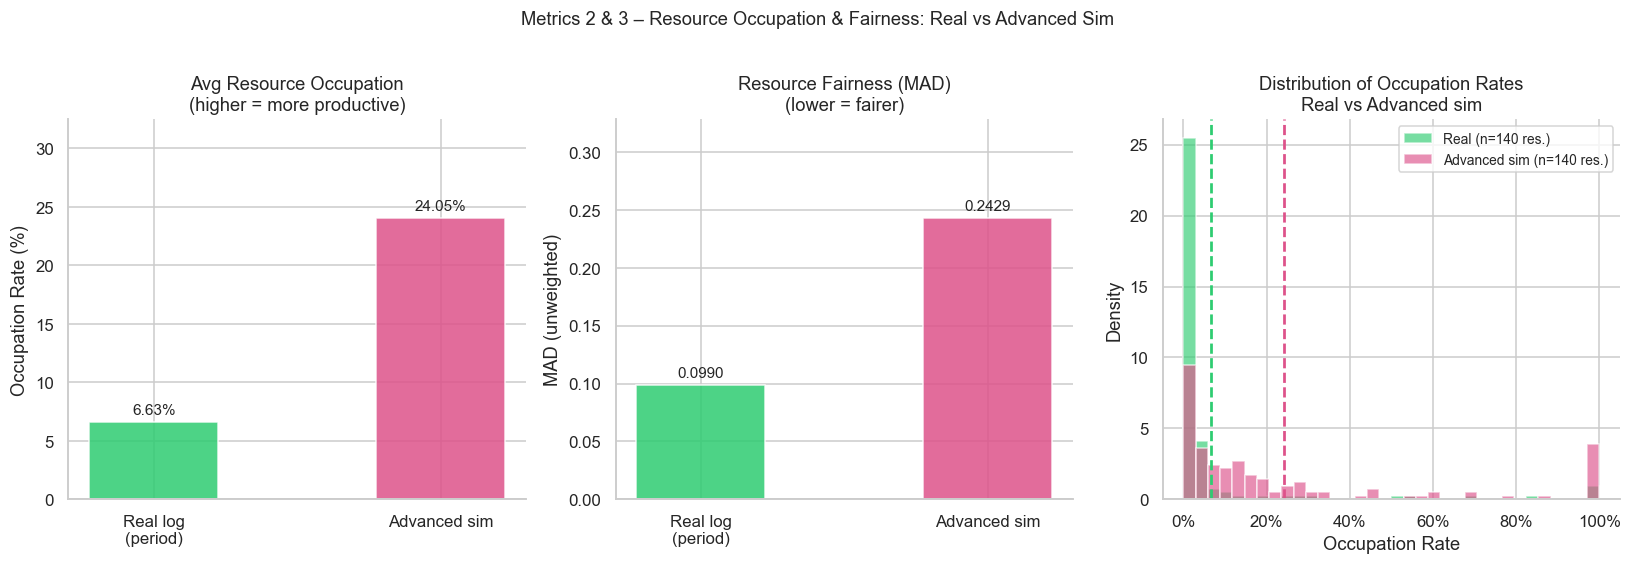

Saved -> results/validation_resource_metrics.png


In [186]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

labels_rv = ['Real log\n(period)', 'Advanced sim']
colors_rv  = [REAL_COLOR, COLORS['advanced']]

# Panel 1: Mean occupation
ax = axes[0]
vals_occ = [r_mean * 100, advanced_occ['occupation'].mean() * 100]
bars = ax.bar(labels_rv, vals_occ, color=colors_rv, alpha=0.85, width=0.45)
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=10)
ax.set_ylabel('Occupation Rate (%)')
ax.set_title('Avg Resource Occupation\n(higher = more productive)')
ax.set_ylim(0, max(vals_occ) * 1.35)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2: Fairness MAD
ax2 = axes[1]
vals_mad = [r_mad, a_mad]
bars2 = ax2.bar(labels_rv, vals_mad, color=colors_rv, alpha=0.85, width=0.45)
ax2.bar_label(bars2, fmt='%.4f', padding=3, fontsize=10)
ax2.set_ylabel('MAD (unweighted)')
ax2.set_title('Resource Fairness (MAD)\n(lower = fairer)')
ax2.set_ylim(0, max(vals_mad) * 1.35)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# Panel 3: Occupation distribution
ax3 = axes[2]
bins = np.linspace(0, 1, 35)
ax3.hist(real_occ_period['occupation'], bins=bins, alpha=0.65, color=REAL_COLOR,
         density=True, label=f'Real (n={len(real_occ_period)} res.)')
ax3.hist(advanced_occ['occupation'], bins=bins, alpha=0.65, color=COLORS['advanced'],
         density=True, label=f'Advanced sim (n={len(advanced_occ)} res.)')
ax3.axvline(r_mean, color=REAL_COLOR,         linestyle='--', lw=1.8)
ax3.axvline(a_mean, color=COLORS['advanced'], linestyle='--', lw=1.8)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax3.set_xlabel('Occupation Rate')
ax3.set_ylabel('Density')
ax3.set_title('Distribution of Occupation Rates\nReal vs Advanced sim')
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

plt.suptitle('Metrics 2 & 3 – Resource Occupation & Fairness: Real vs Advanced Sim',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validation_resource_metrics.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved -> results/validation_resource_metrics.png')

### Metric 3 (supplement) – Fairness Detail: Best Run vs Real Log

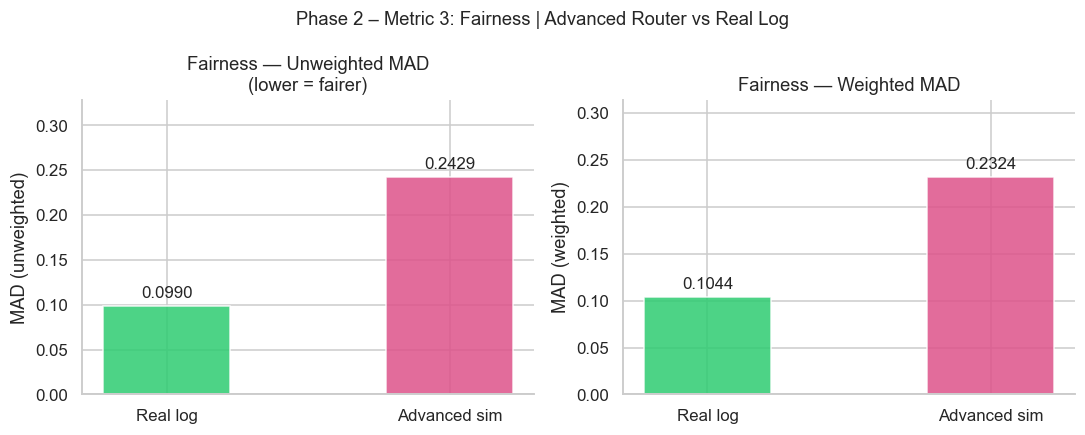

MAD  — Real: 0.0990   Advanced: 0.2429
wMAD — Real: 0.1044  Advanced: 0.2324


In [187]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels_p2f = ['Real log', 'Advanced sim']
colors_p2f  = [REAL_COLOR, COLORS['advanced']]

ax = axes[0]
bars = ax.bar(labels_p2f, [r_mad, a_mad], color=colors_p2f, alpha=0.85, width=0.45)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylabel('MAD (unweighted)'); ax.set_title('Fairness — Unweighted MAD\n(lower = fairer)')
ax.set_ylim(0, max(r_mad, a_mad) * 1.35)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax2 = axes[1]
bars2 = ax2.bar(labels_p2f, [r_wmad, a_wmad], color=colors_p2f, alpha=0.85, width=0.45)
ax2.bar_label(bars2, fmt='%.4f', padding=3)
ax2.set_ylabel('MAD (weighted)'); ax2.set_title('Fairness — Weighted MAD')
ax2.set_ylim(0, max(r_wmad, a_wmad) * 1.35)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('Phase 2 – Metric 3: Fairness | Advanced Router vs Real Log', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'p2_advanced_fairness_vs_real.png', bbox_inches='tight')
plt.show()
print(f"MAD  — Real: {r_mad:.4f}   Advanced: {a_mad:.4f}")
print(f"wMAD — Real: {r_wmad:.4f}  Advanced: {a_wmad:.4f}")


### Metric 4 – Outcome Distribution Fidelity: Best Run vs Real Log

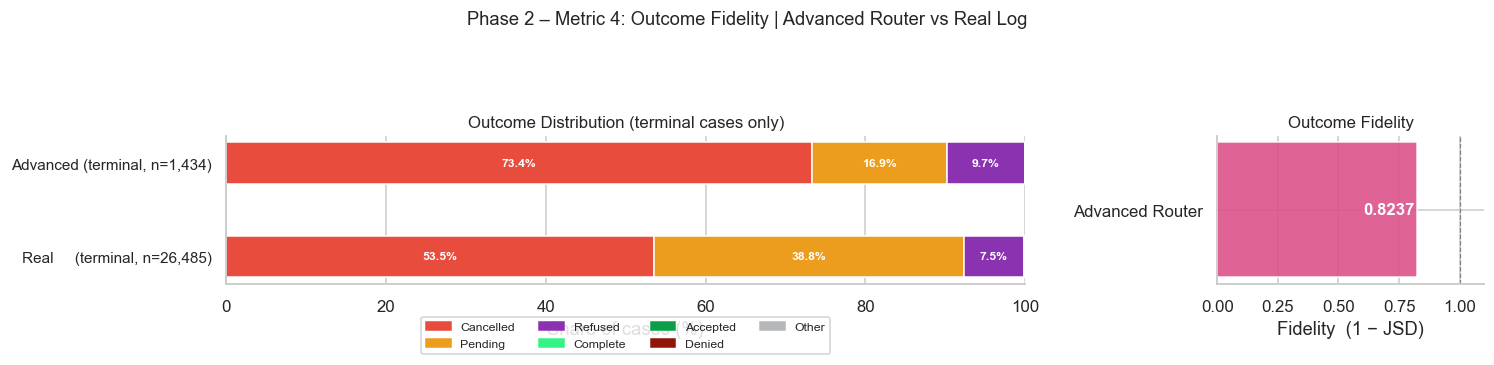

Advanced — JSD: 0.1763   Fidelity: 0.8237


In [188]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), gridspec_kw={'width_ratios': [3, 1]})

rows_p2 = [
    (f'Real     (terminal, n={n_real_terminal:,})',    real_dist_out),
    (f'Advanced (terminal, n={n_adv_terminal:,})', adv_dist_out),
]
ax = axes[0]
bar_h = 0.45
for i, (label, dist) in enumerate(rows_p2):
    left = 0.0
    for cat in OUTCOME_CATEGORIES:
        val = dist[cat] * 100
        ax.barh(i, val, bar_h, left=left, color=OUTCOME_COLORS[cat],
                label=cat if i == 0 else '')
        if val >= 4:
            ax.text(left + val / 2, i, f'{val:.1f}%',
                    ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        left += val
ax.set_yticks(range(len(rows_p2))); ax.set_yticklabels([r[0] for r in rows_p2], fontsize=10)
ax.set_xlabel('Share of cases (%)'); ax.set_xlim(0, 100)
ax.set_title('Outcome Distribution (terminal cases only)', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
handles = [mpatches.Patch(color=OUTCOME_COLORS[c], label=c) for c in OUTCOME_CATEGORIES]
ax.legend(handles=handles, fontsize=8, ncol=4, loc='upper center',
          bbox_to_anchor=(0.5, -0.18), framealpha=0.85)

ax2 = axes[1]
bars = ax2.barh(['Advanced Router'], [fidelity_a], color=[COLORS['advanced']], alpha=0.9, height=0.4)
for bar, val in zip(bars, [fidelity_a]):
    ax2.text(val - 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', ha='right', va='center', fontsize=11, color='white', fontweight='bold')
ax2.set_xlim(0, 1.1); ax2.axvline(1.0, color='grey', linestyle='--', lw=0.8)
ax2.set_xlabel('Fidelity  (1 − JSD)'); ax2.set_title('Outcome Fidelity', fontsize=11)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('Phase 2 – Metric 4: Outcome Fidelity | Advanced Router vs Real Log', fontsize=12, y=1.05)
plt.tight_layout(pad=2.0)
plt.savefig(RESULTS_DIR / 'p2_advanced_fidelity_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Advanced — JSD: {jsd_a:.4f}   Fidelity: {fidelity_a:.4f}")


## Phase 4 – All Configs vs Real Log

Compares each allocation config against the real log across all four metrics.

> **How metrics are computed:** Each config has 5 replications. Because case IDs restart from 1 in every run, concatenating runs would mix events from different replications under the same case ID and corrupt cycle time and occupation calculations. Instead, **all four metrics are computed independently for each run and then averaged** across the 5 replications per config.

In [189]:
_P4_START = datetime.date(2016, 5, 17)
_P4_END   = datetime.date(2016, 5, 31)   # 14-day window

# Real log reference values for Phase 4
_real_ct_p4    = compute_cycle_times(real_log)
_real_ct_p4_f  = _real_ct_p4[_real_ct_p4 > 2]
_real_work_p4  = compute_working_seconds(real_log)
_real_avail_p4 = compute_available_seconds(avail_df, _P4_START, _P4_END)
_real_occ_p4   = compute_occupation(_real_work_p4, _real_avail_p4)
_real_dist_p4  = outcome_dist(classify_outcomes(real_log, terminal_filter=True))

metric_rows = []

for cfg_name, cfg_dir in _CONFIG_DIRS.items():
    run_files = sorted(cfg_dir.glob("run_*.csv"))
    if not run_files:
        print(f"[skip] {cfg_name}: no data")
        continue

    # Compute metrics per run, then average — case IDs restart at 1 each run
    # so concatenation would corrupt groupby results.
    per_run = []
    avail_p4 = compute_available_seconds(avail_df, _P4_START, _P4_END)

    for f in run_files:
        df = pd.read_csv(f, parse_dates=["time:timestamp"])

        ct   = compute_cycle_times(df)
        ct_f = ct[ct > 2]

        work = compute_working_seconds(df)
        occ  = compute_occupation(work, avail_p4)
        _, mad, _ = fairness_metrics(occ["occupation"], occ["available_seconds"])

        outcomes = classify_outcomes(df, terminal_filter=True)
        fidelity = 1 - jsd_outcomes(_real_dist_p4, outcome_dist(outcomes))

        per_run.append({
            "CT Mean (h)":      ct_f.mean(),
            "CT Median (h)":    ct_f.median(),
            "Occ Mean":         occ["occupation"].mean(),
            "Fairness MAD":     mad,
            "Outcome Fidelity": fidelity,
            "N cases":          df["case:concept:name"].nunique(),
        })

    avg = pd.DataFrame(per_run).mean()
    metric_rows.append({"Config": cfg_name, **avg.to_dict()})

# Summary table with real log row prepended
metrics_df = pd.DataFrame(metric_rows)
real_ref = pd.DataFrame([{
    "Config":           "REAL LOG",
    "CT Mean (h)":      _real_ct_p4_f.mean(),
    "CT Median (h)":    _real_ct_p4_f.median(),
    "Occ Mean":         _real_occ_p4["occupation"].mean(),
    "Fairness MAD":     float("nan"),
    "Outcome Fidelity": 1.0,
    "N cases":          real_log["case:concept:name"].nunique(),
}])
metrics_df = pd.concat([real_ref, metrics_df], ignore_index=True)
metrics_df

,Config,CT Mean (h),CT Median (h),Occ Mean,Fairness MAD,Outcome Fidelity,N cases
0,REAL LOG,527.412900,460.889025,0.655726,NaN,1.000000,31509.0
1,shortest_queue,17.520890,15.528617,0.267350,0.295445,0.664531,1972.0
2,advanced_local_d5,14.192813,14.513582,0.072483,0.090789,0.668215,406.0
3,advanced_global_d100,15.238383,14.215911,0.245491,0.256870,0.671804,1511.2


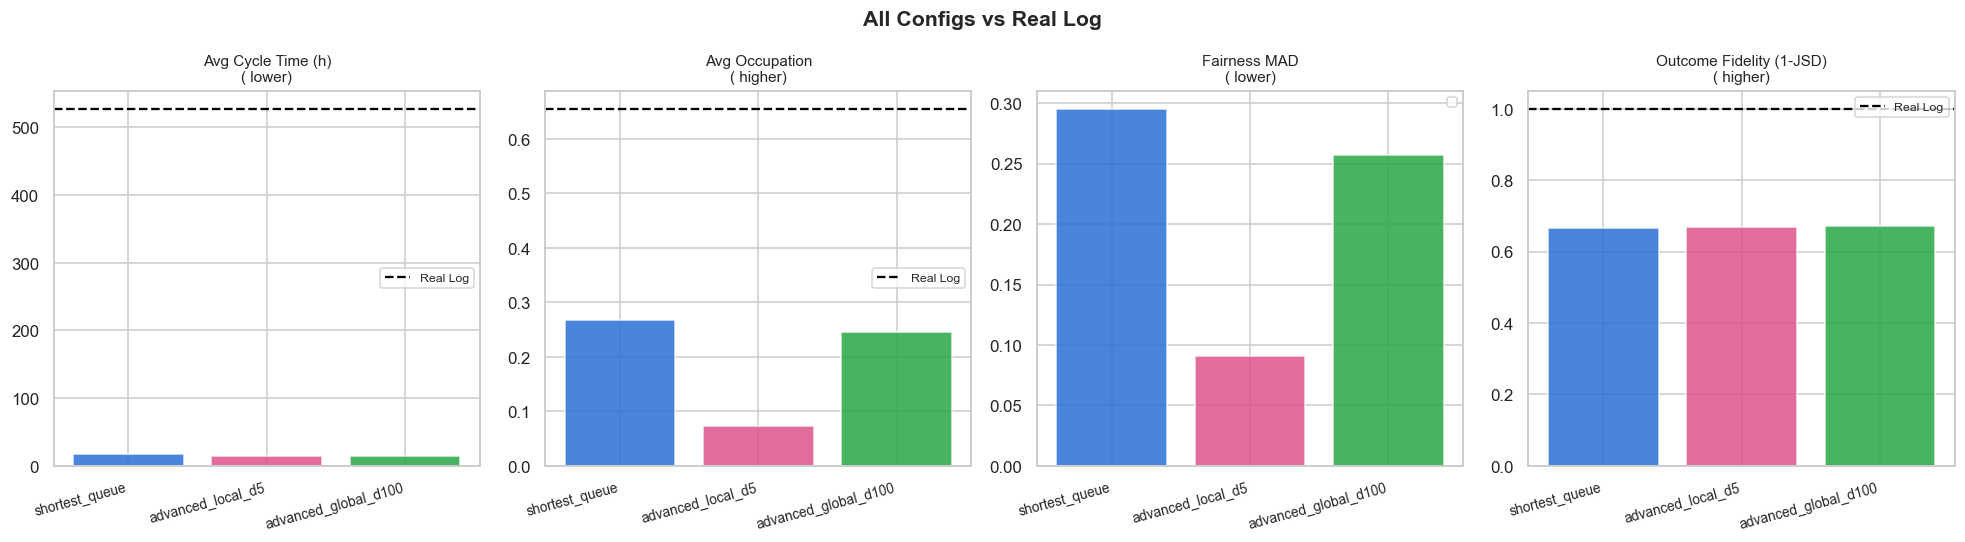

Saved -> results/phase4_configs_vs_real.png


In [190]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("All Configs vs Real Log", fontsize=14, fontweight='bold')

real_row = metrics_df[metrics_df["Config"] == "REAL LOG"].iloc[0]
sim_rows = metrics_df[metrics_df["Config"] != "REAL LOG"]

cfg_colors = ["#2870D5", "#DD528A", "#28A745"]

for ax, (col, label, better) in zip(axes, [
    ("CT Mean (h)",      "Avg Cycle Time (h)",     " lower"),
    ("Occ Mean",         "Avg Occupation",          " higher"),
    ("Fairness MAD",     "Fairness MAD",            " lower"),
    ("Outcome Fidelity", "Outcome Fidelity (1-JSD)", " higher"),
]):
    vals = sim_rows[col].values
    cfgs = sim_rows["Config"].values
    ax.bar(range(len(cfgs)), vals, color=cfg_colors[:len(cfgs)], alpha=0.85, edgecolor='white')
    if col != "Fairness MAD" and not pd.isna(real_row[col]):
        ax.axhline(real_row[col], color='black', linewidth=1.5, linestyle='--', label='Real Log')
    ax.set_xticks(range(len(cfgs)))
    ax.set_xticklabels(cfgs, rotation=15, ha='right', fontsize=9)
    ax.set_title(f"{label}\n({better})", fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase4_configs_vs_real.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved -> results/phase4_configs_vs_real.png')

### Last Activity Distribution – All Configs

Shows the distribution of each case's **last recorded activity** across all three allocation configs (averaged over replications) and the real log. This reveals how different routing strategies affect which activities cases tend to end on.

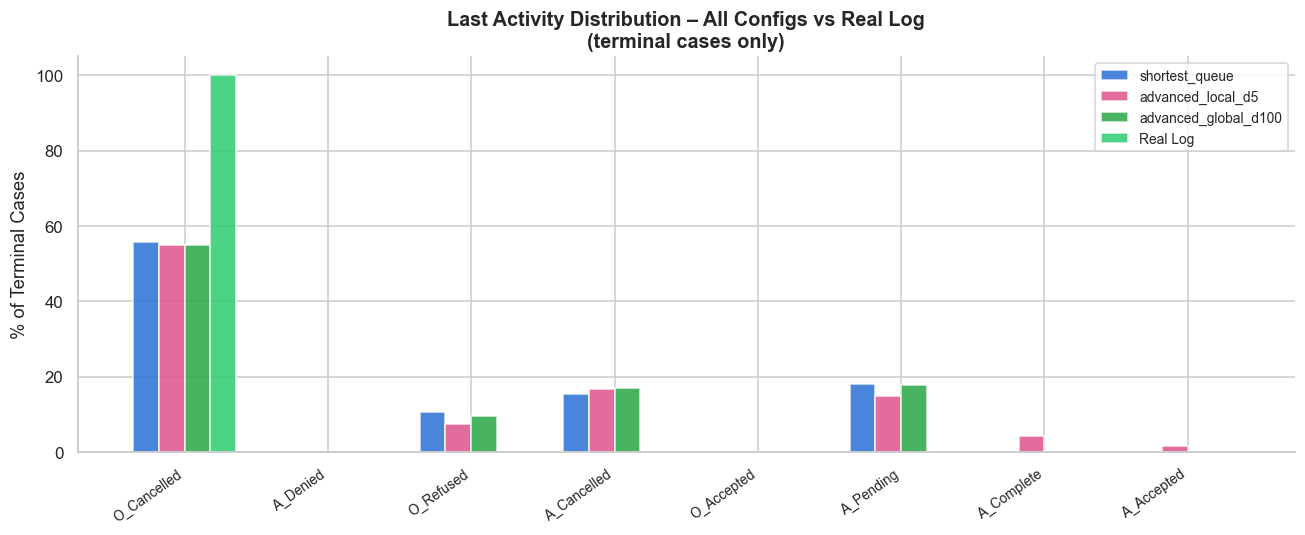

Saved -> results/phase4_last_activity_dist.png


In [191]:
# Last activity distribution across all configs (averaged over replications) + real log
# Only terminal cases are included (last activity ∈ TERMINAL_ACTS) to avoid right-censored
# in-flight cases skewing the distribution with intermediate activities like W_Validate.

def last_activity_dist(df):
    """Return normalised frequency dict of last activity per case (terminal cases only)."""
    last = (
        df.sort_values('time:timestamp')
          .groupby('case:concept:name')['concept:name']
          .last()
    )
    last = last[last.isin(TERMINAL_ACTS)]   # drop right-censored / in-flight cases
    counts = last.value_counts()
    return (counts / counts.sum()).to_dict()

# Collect per-config averaged distributions
_la_cfg_dists = {}
for cfg_name, cfg_dir in _CONFIG_DIRS.items():
    run_files = sorted(cfg_dir.glob("run_*.csv"))
    if not run_files:
        continue
    per_run = []
    for f in run_files:
        df = pd.read_csv(f, parse_dates=["time:timestamp"])
        per_run.append(last_activity_dist(df))
    all_acts = sorted({a for d in per_run for a in d})
    avg_dist  = {a: np.mean([d.get(a, 0.0) for d in per_run]) for a in all_acts}
    _la_cfg_dists[cfg_name] = avg_dist

# Real log — same terminal filter applied for fair comparison
_la_real_dist = last_activity_dist(real_log)

# Activities sorted by real log frequency descending
all_activities = sorted(
    {a for d in list(_la_cfg_dists.values()) + [_la_real_dist] for a in d},
    key=lambda a: -_la_real_dist.get(a, 0)
)

# Build plot
n_acts   = len(all_activities)
n_groups = len(_la_cfg_dists) + 1
bar_w    = 0.18
x        = np.arange(n_acts)

_LA_COLORS = ['#2870D5', '#DD528A', '#28A745', REAL_COLOR]

fig, ax = plt.subplots(figsize=(max(12, n_acts * 1.4), 5))

for i, (label, dist) in enumerate(
    list(_la_cfg_dists.items()) + [("Real Log", _la_real_dist)]
):
    freqs  = [dist.get(a, 0.0) * 100 for a in all_activities]
    offset = (i - n_groups / 2 + 0.5) * bar_w
    ax.bar(x + offset, freqs, bar_w, label=label,
           color=_LA_COLORS[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(all_activities, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('% of Terminal Cases')
ax.set_title('Last Activity Distribution – All Configs vs Real Log\n(terminal cases only)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase4_last_activity_dist.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved -> results/phase4_last_activity_dist.png')